# Reservoir Computing — Training Pipeline & Network Theory

> Second Meeting — Emilio's Notes

## 2 subgroups:

- **Check the Network from the data** → Properties → explorative → more data
- **Set up the Reservoir** to make it start learning (Echo State Network)



## 1. Full Reservoir Dynamics (with Input)

 **How to build the Echo State Net** → implementation:

We now include the **input term** in the reservoir equation.
Illustrated with a small 3-neuron example in the notes:

$$\frac{dr_i}{dt} = -r_i(t) + S\!\left(\sum_{j=1}^{N} W_{ij}\, r_j(t)
  + \sum_{j} W^{\text{in}}_{ij}\, h_j(t)\right)$$

Where:
- $W$ = internal reservoir weight matrix ($N \times N$), **fixed**
- $W^{\text{in}}$ = input weight matrix, **fixed**
- $h(t)$ = external input signal (e.g., Lorenz trajectory)
- $S(\cdot)$ = nonlinear activation function (e.g., tanh)
- $N$ = number of reservoir neurons

> The reservoir receives both its own recurrent activity and the external input $h(t)$.

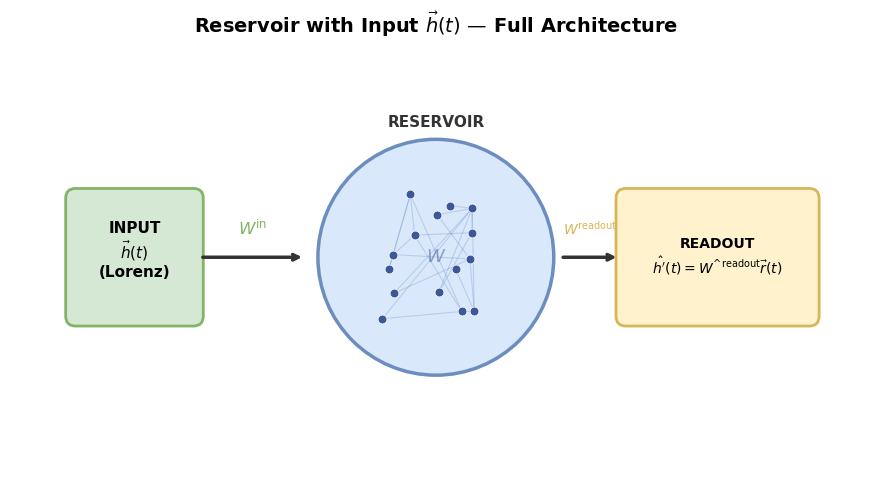

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
from scipy.stats import poisson
import networkx as nx

# Diagram: reservoir with input
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
ax.set_xlim(-1, 12)
ax.set_ylim(-1, 5.5)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('white')

# Input box
input_box = mpatches.FancyBboxPatch((0, 1.5), 1.8, 1.8,
    boxstyle="round,pad=0.15", facecolor='#D5E8D4', edgecolor='#82B366', linewidth=2)
ax.add_patch(input_box)
ax.text(0.9, 2.5, 'INPUT\n$\\vec{h}(t)$\n(Lorenz)', ha='center', va='center',
        fontsize=11, fontweight='bold')

# Reservoir circle
reservoir = plt.Circle((5.5, 2.4), 1.8, facecolor='#DAE8FC',
                        edgecolor='#6C8EBF', linewidth=2.5)
ax.add_patch(reservoir)
ax.text(5.5, 4.45, 'RESERVOIR', ha='center', va='center',
        fontsize=11, fontweight='bold', color='#333')

# Nodes inside reservoir
np.random.seed(42)
n_nodes = 15
angles = (np.linspace(0, 2*np.pi, n_nodes, endpoint=False)
          + np.random.uniform(-0.2, 0.2, n_nodes))
radii = np.random.uniform(0.3, 1.5, n_nodes)
node_x = 5.5 + radii * np.cos(angles)
node_y = 2.4 + radii * np.sin(angles)

np.random.seed(7)
for i in range(n_nodes):
    targets = np.random.choice(n_nodes, np.random.randint(1, 4), replace=False)
    for t in targets:
        if t != i:
            ax.plot([node_x[i], node_x[t]], [node_y[i], node_y[t]],
                    color='#6C8EBF', alpha=0.3, linewidth=0.8)
ax.scatter(node_x, node_y, s=40, c='#3B5998', zorder=5,
           edgecolors='white', linewidth=0.5)

ax.annotate('', xy=(3.5, 2.4), xytext=(1.9, 2.4),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#333'))
ax.text(2.7, 2.75, '$W^{\\text{in}}$', ha='center', fontsize=12,
        color='#82B366', fontweight='bold')

# Readout box
readout_box = mpatches.FancyBboxPatch((8.4, 1.5), 2.8, 1.8,
    boxstyle="round,pad=0.15", facecolor='#FFF2CC', edgecolor='#D6B656', linewidth=2)
ax.add_patch(readout_box)
ax.text(9.8, 2.4, "READOUT\n$\\hat{h'}(t)=W^{\\text{^readout}}\\vec{r}(t)$",
        ha='center', va='center', fontsize=10, fontweight='bold')

ax.annotate('', xy=(8.3, 2.4), xytext=(7.4, 2.4),
            arrowprops=dict(arrowstyle='->', lw=2.5, color='#333'))
ax.text(7.85, 2.75, '$W^{\\text{readout}}$', ha='center', fontsize=10,
        color='#D6B656', fontweight='bold')

ax.text(5.5, 2.4, '$W$', ha='center', va='center', fontsize=13,
        color='#3B5998', fontweight='bold', alpha=0.5)

ax.set_title("Reservoir with Input $\\vec{h}(t)$ — Full Architecture",
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 2. Training Pipeline — 5 Steps

### Step ① — Pre-compute the Lorenz Attractor (Thermalize)

- Run the Lorenz system **long enough to thermalize** — to land on the attractor
- Discard the initial transient; use only the **attractor trajectory** as input $\vec{h}(t)$
- This ensures the input is chaotic and structured — **difficult to predict**


**Practical constraints:**
- No networks larger than $N \leq 300$
- Maybe start with $N = 100$

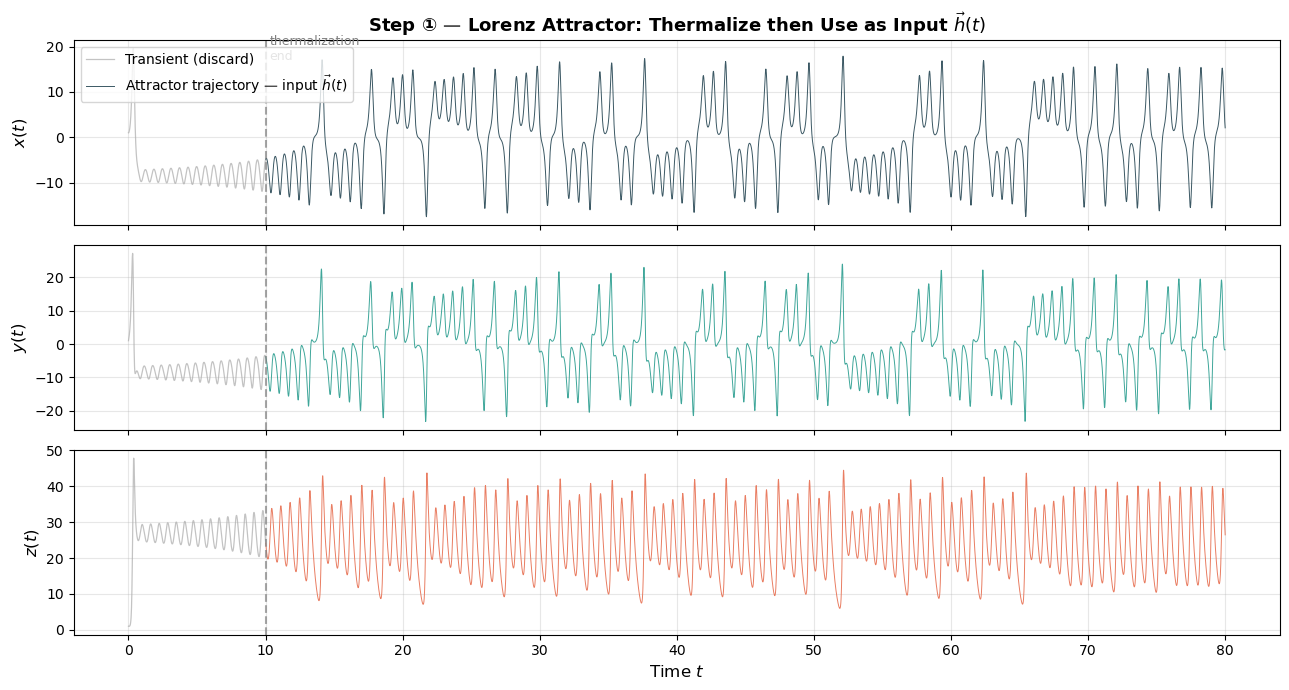

In [2]:
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma*(y - x), x*(rho - z) - y, x*y - beta*z]

T_total = 80
sol = solve_ivp(lorenz, [0, T_total], [1.0, 1.0, 1.0],
                max_step=0.01, dense_output=True)

T_therm = 10
mask = sol.t >= T_therm

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
labels_xyz = ['$x(t)$', '$y(t)$', '$z(t)$']
colors_xyz = ['#264653', '#2A9D8F', '#E76F51']

for i, (label, color) in enumerate(zip(labels_xyz, colors_xyz)):
    axes[i].plot(sol.t[~mask], sol.y[i][~mask],
                 linewidth=0.9, color='#aaaaaa', alpha=0.7,
                 label='Transient (discard)' if i == 0 else None)
    axes[i].plot(sol.t[mask], sol.y[i][mask],
                 linewidth=0.7, color=color, alpha=0.9,
                 label='Attractor trajectory — input $\\vec{h}(t)$' if i == 0 else None)
    axes[i].axvline(x=T_therm, color='gray', linestyle='--', alpha=0.7)
    axes[i].set_ylabel(label, fontsize=12)
    axes[i].grid(True, alpha=0.3)

axes[0].text(T_therm + 0.3, axes[0].get_ylim()[1] * 0.8,
             'thermalization\nend', fontsize=9, color='gray')
axes[0].set_title(
    'Step ① — Lorenz Attractor: Thermalize then Use as Input $\\vec{h}(t)$',
    fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[2].set_xlabel('Time $t$', fontsize=12)
plt.tight_layout()
plt.show()

### Step ② — Simulate the Reservoir

Drive the reservoir with the input $\vec{h}(t)$ to obtain the reservoir state $\vec{r}(t)$:

$$\vec{h}(t) \;\longrightarrow\; \vec{r}(t)$$

Concretely, via the Euler discretization:

$$r_i(t + \Delta t) = r_i(t) + \Delta t \left[-r_i(t)
  + S\!\left(\sum_j W_{ij}\, r_j(t) + W^{\text{in}}_i\, h(t)\right)\right]$$

**Store history:** matrix $R$ of shape $N \times T$  ($N$ neurons, $T$ time steps).
This matrix is the key ingredient for regression.

### Step ③ — Compute the Readout

$$\hat{h'}(t) = W^{\text{readout}} \cdot \vec{r}(t)$$

The output is a **linear combination of reservoir states**.
$W^{\text{readout}}$ is the **only trained part** of the system.

### Step ④ — Ridge Regression for $W^{\text{readout}}$

We want to find $W^{\text{readout}}$ such that the output predicts the **next time step**:

$$\vec{h'}(t) = h(t + \Delta t)$$

**Method:** Ridge Regression (regularized least squares)

$$W^{\text{readout}} = \arg\min_{W} \left\| W \cdot R - H_{\text{target}} \right\|^2
  + \lambda \|W\|^2$$

Where:
- $R$ = reservoir state matrix ($N \times T$)
- $H_{\text{target}}$ = shifted input $h(t + \Delta t)$ (target values)
- $\lambda$ = regularization parameter

> "The output is predicting the next input."

**Data strategy: SERIES SHOULD OVERLAP → No risk of overfitting**
(the readout is a linear layer — no deep model to overfit)

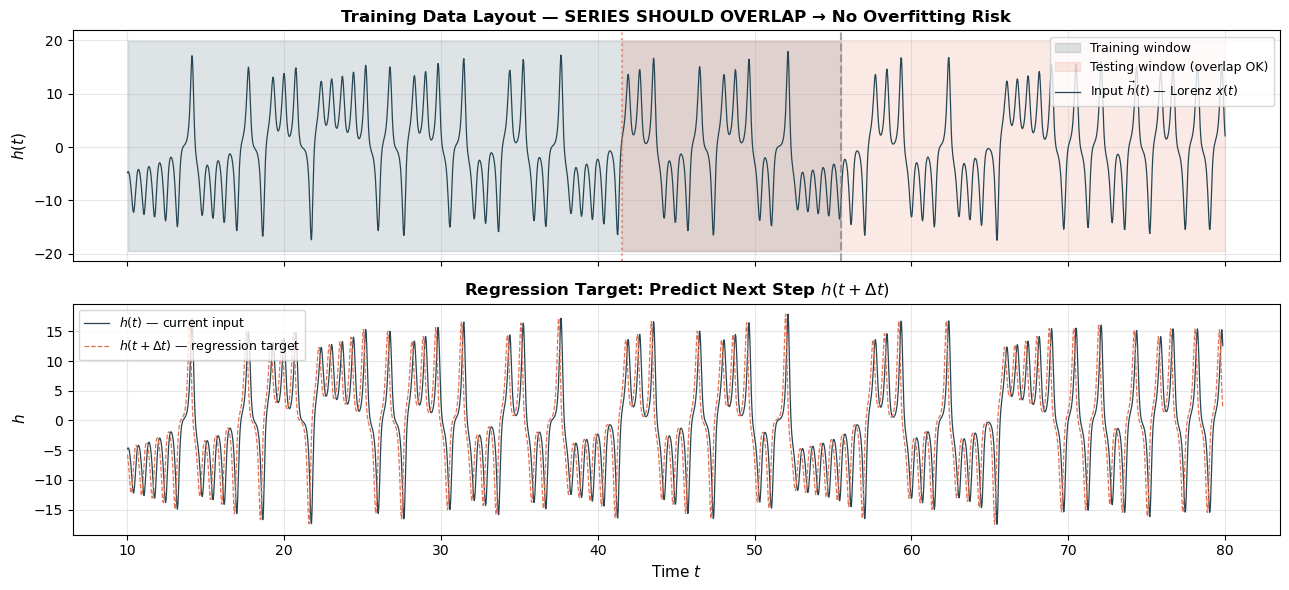

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

u = sol.y[0][mask][::3]
t_u = sol.t[mask][::3]
T_len = len(u)
train_end_idx = int(0.65 * T_len)
test_start_idx = int(0.45 * T_len)

axes[0].fill_betweenx([u.min() - 2, u.max() + 2],
                       t_u[0], t_u[train_end_idx],
                       alpha=0.15, color='#264653', label='Training window')
axes[0].fill_betweenx([u.min() - 2, u.max() + 2],
                       t_u[test_start_idx], t_u[-1],
                       alpha=0.15, color='#E76F51', label='Testing window (overlap OK)')
axes[0].plot(t_u, u, color='#264653', linewidth=0.9,
             label='Input $\\vec{h}(t)$ — Lorenz $x(t)$')
axes[0].axvline(x=t_u[train_end_idx], color='gray', linestyle='--', alpha=0.7)
axes[0].axvline(x=t_u[test_start_idx], color='#E76F51', linestyle=':', alpha=0.7)
axes[0].set_title(
    'Training Data Layout — SERIES SHOULD OVERLAP → No Overfitting Risk',
    fontsize=12, fontweight='bold')
axes[0].set_ylabel('$h(t)$', fontsize=11)
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(True, alpha=0.3)

dt_shift = 5
axes[1].plot(t_u[:-dt_shift], u[:-dt_shift], color='#264653',
             linewidth=0.9, label='$h(t)$ — current input')
axes[1].plot(t_u[:-dt_shift], u[dt_shift:], color='#E76F51',
             linewidth=0.9, linestyle='--',
             label='$h(t+\\Delta t)$ — regression target')
axes[1].set_title('Regression Target: Predict Next Step $h(t+\\Delta t)$',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time $t$', fontsize=11)
axes[1].set_ylabel('$h$', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<!-- ### Step ⑤ — Testing & Validation -->

1. Let the Net **Run** and at some $t_0$ (far enough)
2. **Substitute** $\vec{h}(t)$ with $\vec{h'}(t)$
   — replace the true Lorenz input with the reservoir's own predicted output
   (autonomous / generative mode)
3. **Do the whole procedure 5 times** and look at the error (MSE)

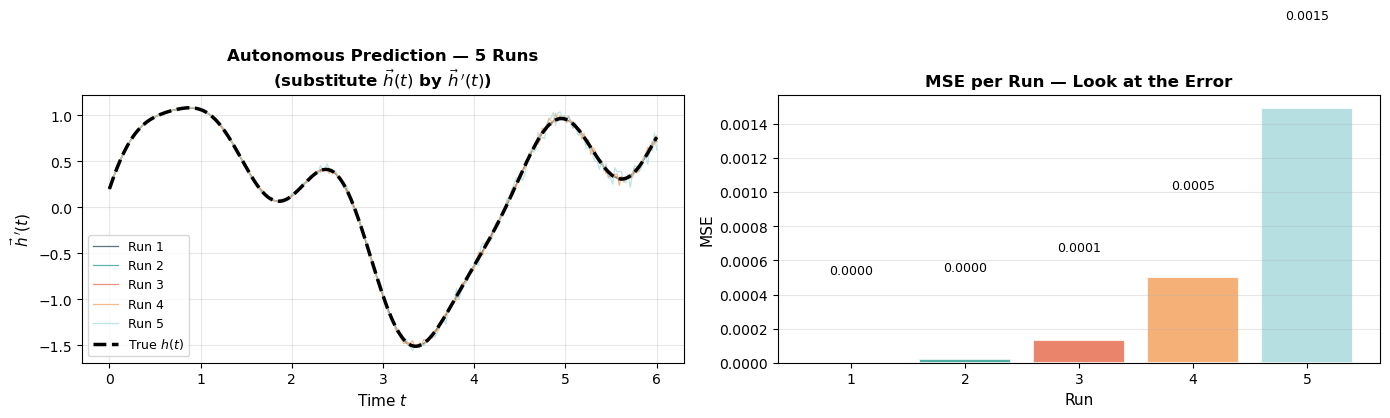

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

np.random.seed(3)
t_test = np.linspace(0, 6, 250)
true_signal = (np.sin(1.4 * t_test) + 0.5 * np.sin(3.1 * t_test)
               + 0.2 * np.cos(5 * t_test))

run_colors = ['#264653', '#2A9D8F', '#E76F51', '#F4A261', '#A8DADC']
errors = []

for run in range(5):
    np.random.seed(run * 13)
    divergence = np.exp(np.linspace(0, run * 0.4, len(t_test)) * 0.3) - 1
    noise = (np.random.randn(len(t_test)) * 0.05
             * (1 + run * 0.3) * divergence)
    pred = true_signal + noise
    axes[0].plot(t_test, pred, linewidth=0.9, alpha=0.75,
                 color=run_colors[run], label=f'Run {run+1}')
    errors.append(np.mean((pred - true_signal)**2))

axes[0].plot(t_test, true_signal, color='black', linewidth=2.5,
             linestyle='--', label='True $h(t)$', zorder=10)
axes[0].set_title(
    'Autonomous Prediction — 5 Runs\n'
    '(substitute $\\vec{h}(t)$ by $\\vec{h}\\,\'(t)$)',
    fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time $t$', fontsize=11)
axes[0].set_ylabel("$\\vec{h}\\,'(t)$", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(range(1, 6), errors, color=run_colors,
                   edgecolor='white', linewidth=1.5, alpha=0.85)
axes[1].set_title('MSE per Run — Look at the Error',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Run', fontsize=11)
axes[1].set_ylabel('MSE', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, err in zip(bars, errors):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.0005,
                 f'{err:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---

# Page 2 — Parameters, Network Theory & Eigenvalue Structure

---

## 3. Parameter Summary

| Parameter | Value / Note |
|---|---|
| $W^{\text{readout}}$ | **Gaussian Random** — trained by ridge regression |
| $W^{\text{in}}$ | **Gaussian Random** — fixed, size $N$ |
| $N$ | $\leq 300$ (start with $N = 100$) |
| $\Delta t$ | 0.1 – 0.3 → slightly larger value works a bit better; not too small, not too big |
| $J$ | $\approx 1$ (edge of chaos) |

> **If $J > 1$: the network does not train.**

> "Network has a very big memory and $N$ very susceptible to change"

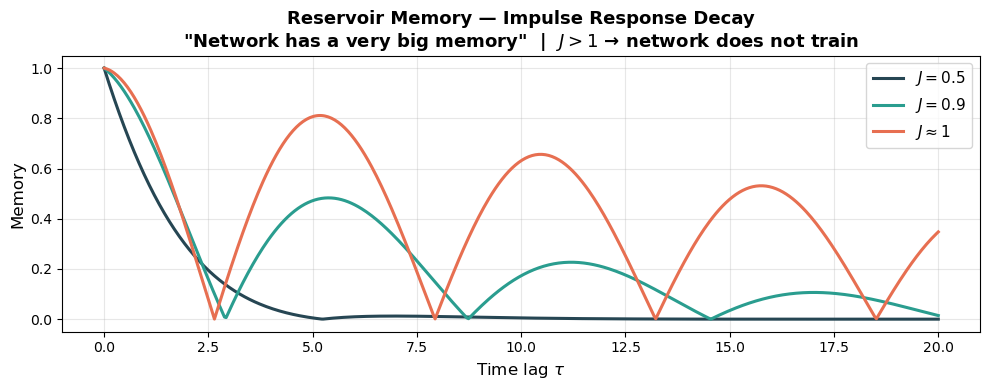

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

t_mem = np.linspace(0, 20, 500)
for J_val, col, lbl in [(0.5, '#264653', '$J=0.5$'),
                         (0.9, '#2A9D8F', '$J=0.9$'),
                         (0.99, '#E76F51', '$J\\approx 1$')]:
    memory = np.exp(-t_mem * (1 - J_val + 0.03)) * np.abs(np.cos(0.6 * t_mem * J_val))
    ax.plot(t_mem, memory, linewidth=2.2, color=col, label=lbl)

ax.set_title('Reservoir Memory — Impulse Response Decay\n'
             '"Network has a very big memory"  |  $J > 1$ → network does not train',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time lag $\\tau$', fontsize=12)
ax.set_ylabel('Memory', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Graph Theory for Reservoir Networks

The **topology** of the reservoir network (which neurons connect to which) matters
for its computational capability.

We use **NetworkX** and the **degree (`deg`) function** to count nodes and
characterise the connectivity:

### Degree Distribution $P(k)$

- Connections are **independent and sparse**
- **Erdős–Rényi (ER) random graph** → Poisson degree distribution
- **(Circled in notes) Scale-free network** → power-law degree distribution:

$$P(k) \sim k^{-\alpha}, \qquad 2 \leq \alpha \leq 3$$

### Distribution of Weights $P(w)$
- The distribution of **edge weights** also matters for reservoir dynamics

Erdős–Rényi:  N = 100 nodes | mean degree = 7.42
Scale-free:   N = 100 nodes | mean degree = 7.68


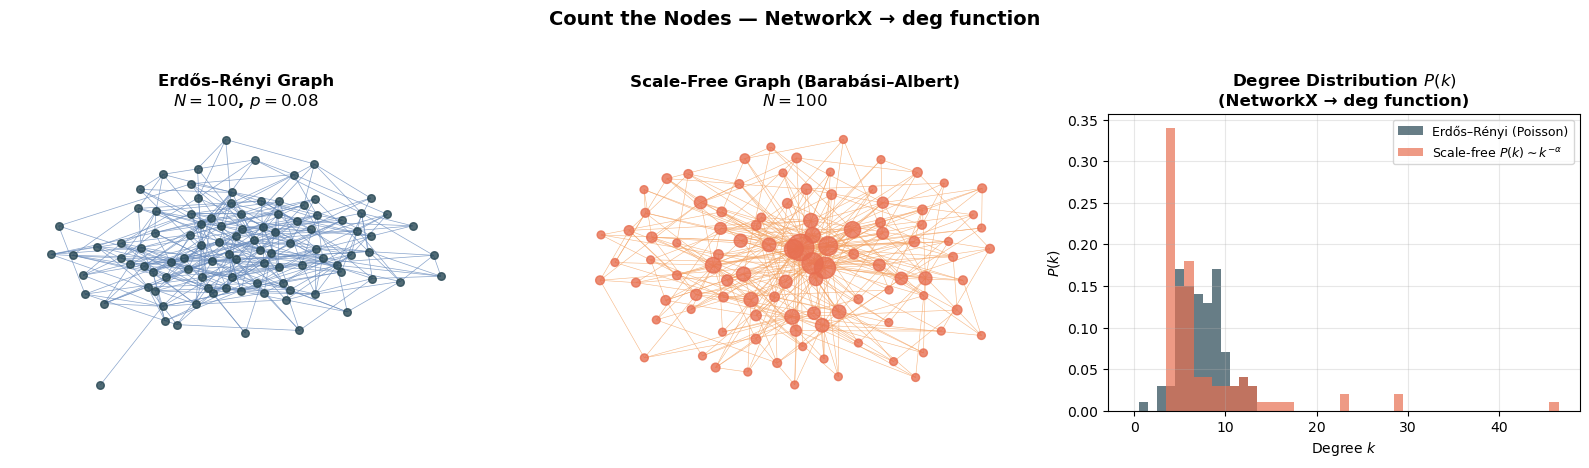

In [6]:
# NetworkX: count nodes and degree distribution
np.random.seed(0)

N_graph = 100
p_connect = 0.08

# Erdős–Rényi reservoir graph
G_er = nx.erdos_renyi_graph(N_graph, p_connect, seed=42)
n_nodes_er = G_er.number_of_nodes()                   # count nodes
degree_sequence_er = [d for _, d in G_er.degree()]    # deg function

# Barabási–Albert (scale-free) graph
G_sf = nx.barabasi_albert_graph(N_graph, 4, seed=42)
degree_sequence_sf = [d for _, d in G_sf.degree()]    # deg function

print(f"Erdős–Rényi:  N = {n_nodes_er} nodes | "
      f"mean degree = {np.mean(degree_sequence_er):.2f}")
print(f"Scale-free:   N = {G_sf.number_of_nodes()} nodes | "
      f"mean degree = {np.mean(degree_sequence_sf):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Draw ER graph
pos_er = nx.spring_layout(G_er, seed=1)
nx.draw_networkx(G_er, pos=pos_er, ax=axes[0], node_size=30,
                 node_color='#264653', edge_color='#6C8EBF',
                 alpha=0.8, with_labels=False, width=0.5)
axes[0].set_title(f'Erdős–Rényi Graph\n$N={N_graph}$, $p={p_connect}$',
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Draw scale-free graph
pos_sf = nx.spring_layout(G_sf, seed=1)
node_sizes_sf = [d * 8 for d in degree_sequence_sf]
nx.draw_networkx(G_sf, pos=pos_sf, ax=axes[1], node_size=node_sizes_sf,
                 node_color='#E76F51', edge_color='#F4A261',
                 alpha=0.8, with_labels=False, width=0.4)
axes[1].set_title(f'Scale-Free Graph (Barabási–Albert)\n$N={N_graph}$',
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

# Degree distributions
max_k = max(max(degree_sequence_er), max(degree_sequence_sf)) + 1
bins = np.arange(0, max_k + 1) - 0.5
axes[2].hist(degree_sequence_er, bins=bins, density=True,
             color='#264653', alpha=0.7, label='Erdős–Rényi (Poisson)')
axes[2].hist(degree_sequence_sf, bins=bins, density=True,
             color='#E76F51', alpha=0.7,
             label='Scale-free $P(k)\\sim k^{-\\alpha}$')
axes[2].set_title('Degree Distribution $P(k)$\n(NetworkX → deg function)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Degree $k$')
axes[2].set_ylabel('$P(k)$')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

fig.suptitle('Count the Nodes — NetworkX → deg function',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 5. Properties of Dynamics — Epidemic Threshold & Erdős–Rényi

### Critical Threshold

$$V_c \sim \frac{\langle k \rangle}{\langle k^2 \rangle}$$

- For **scale-free** networks ($\alpha \leq 3$): $\langle k^2 \rangle \to \infty$
  → $V_c \to 0$ (no threshold — epidemic always spreads)

### Erdős–Rényi: ~40% Would Be Enough

> "If people were connected like Erdős–Rényi → 40% would be enough"

In an Erdős–Rényi network the epidemic threshold is finite and well-defined.
Vaccinating approximately **40% of nodes** is sufficient to stop epidemic spreading
(disrupt the giant connected component / achieve herd immunity).
This contrasts sharply with scale-free networks, where hubs dominate
and random vaccination is far less effective.

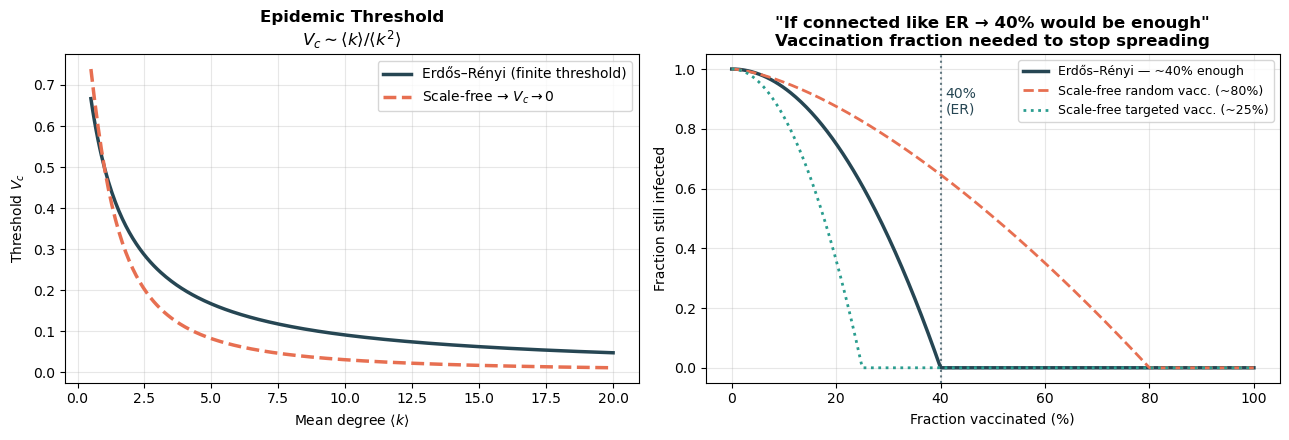

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# V_c vs mean degree
k_mean = np.linspace(0.5, 20, 300)
Vc_ER = 1.0 / (k_mean + 1)           # ER Poisson: <k^2>=<k>^2+<k>
Vc_SF = 1.0 / (k_mean ** 1.5 + 1)    # Scale-free: <k^2> grows fast

axes[0].plot(k_mean, Vc_ER, color='#264653', linewidth=2.5,
             label='Erdős–Rényi (finite threshold)')
axes[0].plot(k_mean, Vc_SF, color='#E76F51', linewidth=2.5,
             linestyle='--', label='Scale-free → $V_c\\to 0$')
axes[0].set_title('Epidemic Threshold\n$V_c \\sim \\langle k\\rangle/\\langle k^2\\rangle$',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean degree $\\langle k \\rangle$')
axes[0].set_ylabel('Threshold $V_c$')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Vaccination fraction needed
frac = np.linspace(0, 1, 400)

# ER: ~40% sufficient
infected_ER = np.where(frac <= 0.4,
                        np.maximum(0, 1 - (frac / 0.4) ** 2), 0.0)
# Scale-free random: needs ~80%
infected_SF_random = np.maximum(0, 1 - (frac / 0.8) ** 1.5)
# Scale-free targeted (hubs): ~25% enough
infected_SF_targeted = np.where(frac <= 0.25,
                                  np.maximum(0, 1 - (frac / 0.25) ** 2), 0.0)

axes[1].plot(frac * 100, infected_ER, color='#264653', linewidth=2.5,
             label='Erdős–Rényi — ~40% enough')
axes[1].plot(frac * 100, infected_SF_random, color='#E76F51', linewidth=2.0,
             linestyle='--', label='Scale-free random vacc. (~80%)')
axes[1].plot(frac * 100, infected_SF_targeted, color='#2A9D8F', linewidth=2.0,
             linestyle=':', label='Scale-free targeted vacc. (~25%)')
axes[1].axvline(x=40, color='#264653', linestyle=':', alpha=0.7)
axes[1].text(41, 0.85, '40%\n(ER)', fontsize=10, color='#264653')
axes[1].set_title('"If connected like ER → 40% would be enough"\n'
                  'Vaccination fraction needed to stop spreading',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fraction vaccinated (%)')
axes[1].set_ylabel('Fraction still infected')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Distribution of Eigenvalues — Circular Law

> "Spectra of our network look like:" — illustrated by the plots below

### Setup

For the **Gaussian random weight matrix** $W$ (size $N \times N$):

$$W_{ij} \sim \mathcal{N}\!\left(0,\, \frac{J^2}{N}\right)$$

the eigenvalues $\lambda$ are **complex numbers**.

### Circular Law (Girko)

$$\lambda \in \mathbb{C}, \qquad |\lambda| \leq J$$

- Eigenvalues fill a **disc of radius $J$** in the complex plane
- **All eigenvalues inside the disc**
- Disc radius $= J$ → coupling strength **directly controls spectral radius**

### Stability Criterion — Connection to Training

| $J$ | Eigenvalues | Dynamics | Training |
|---|---|---|---|
| $J < 1$ | All inside unit circle | Stable | **Network trains** |
| $J = 1$ | Touch unit circle | Edge of chaos | Optimal |
| $J > 1$ | Outside unit circle | Unstable | **Network does not train** |

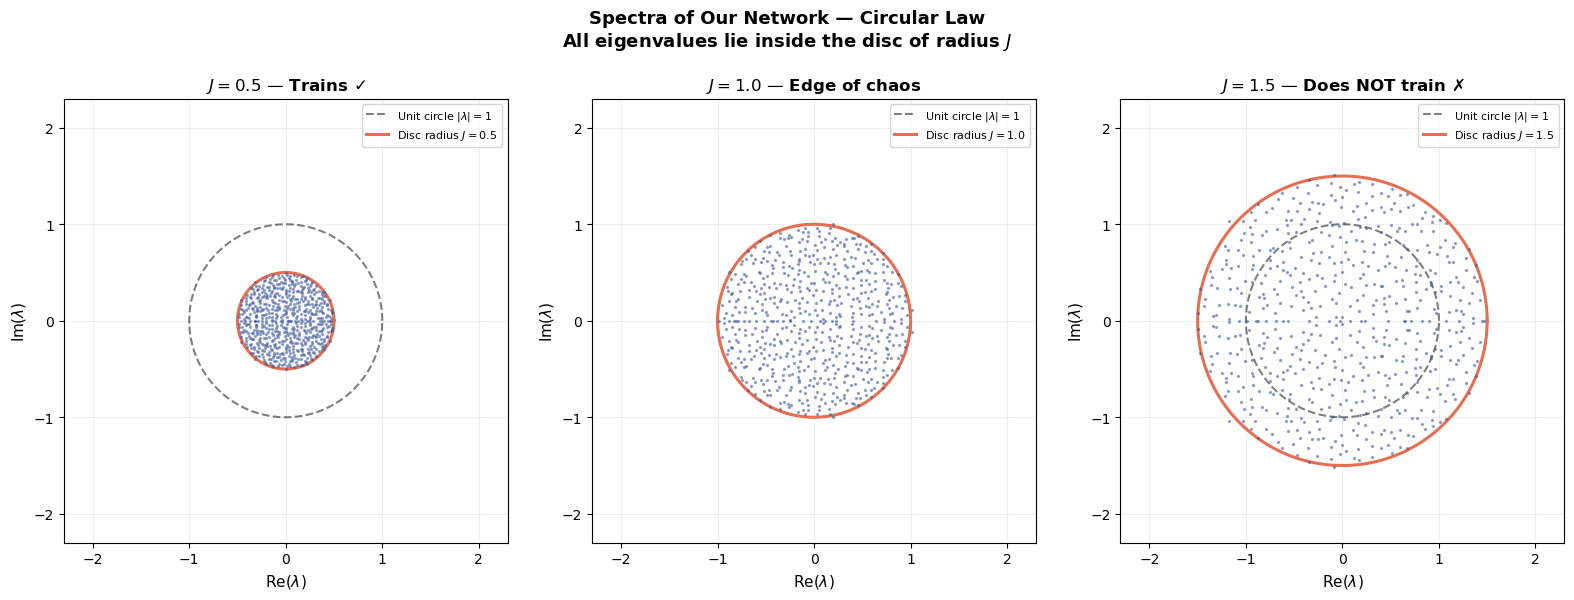

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
J_eig_vals = [0.5, 1.0, 1.5]
N_eig = 600
theta = np.linspace(0, 2 * np.pi, 500)

for idx, J_eig in enumerate(J_eig_vals):
    np.random.seed(idx + 10)
    W_eig = np.random.randn(N_eig, N_eig) * J_eig / np.sqrt(N_eig)
    eigenvalues = np.linalg.eigvals(W_eig)

    axes[idx].scatter(eigenvalues.real, eigenvalues.imag,
                      s=2, alpha=0.45, color='#3B5998', zorder=3)
    axes[idx].plot(np.cos(theta), np.sin(theta), 'k--',
                   linewidth=1.5, alpha=0.5, label='Unit circle $|\\lambda|=1$')
    axes[idx].plot(J_eig * np.cos(theta), J_eig * np.sin(theta),
                   color='#E76F51', linewidth=2.2,
                   label=f'Disc radius $J={J_eig}$')
    axes[idx].set_xlim(-2.3, 2.3)
    axes[idx].set_ylim(-2.3, 2.3)
    axes[idx].set_aspect('equal')
    axes[idx].set_xlabel('Re($\\lambda$)', fontsize=11)
    axes[idx].set_ylabel('Im($\\lambda$)', fontsize=11)

    status = ('Trains ✓' if J_eig < 1.0
              else ('Edge of chaos' if J_eig == 1.0 else 'Does NOT train ✗'))
    axes[idx].set_title(f'$J = {J_eig}$ — {status}',
                        fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=8, loc='upper right')
    axes[idx].grid(True, alpha=0.2)

fig.suptitle(
    'Spectra of Our Network — Circular Law\n'
    'All eigenvalues lie inside the disc of radius $J$',
    fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 7. Spectra of Other Matrices

> "Spectra of other matrices look like:" — two reference examples

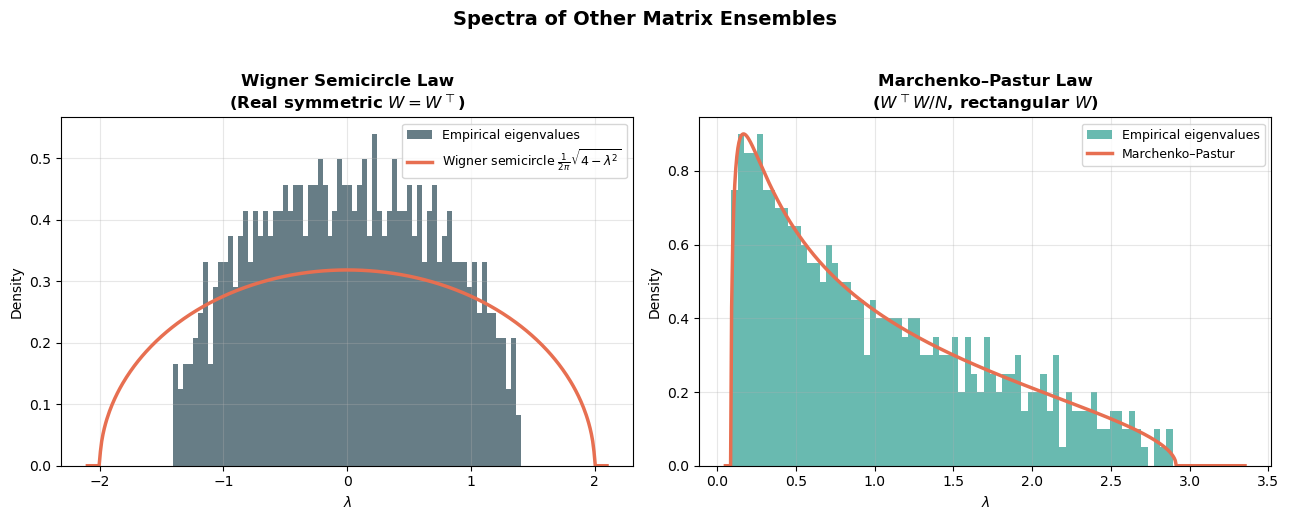

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Wigner Semicircle Law (real symmetric matrix) ---
N_w = 600
np.random.seed(42)
A = np.random.randn(N_w, N_w)
W_sym = (A + A.T) / (2 * np.sqrt(N_w))
eigs_sym = np.linalg.eigvalsh(W_sym)

x_sc = np.linspace(-2.1, 2.1, 400)
semicircle = np.sqrt(np.maximum(0, 4 - x_sc**2)) / (2 * np.pi)

axes[0].hist(eigs_sym, bins=70, density=True,
             color='#264653', alpha=0.7, edgecolor='none',
             label='Empirical eigenvalues')
axes[0].plot(x_sc, semicircle, color='#E76F51', linewidth=2.5,
             label='Wigner semicircle $\\frac{1}{2\\pi}\\sqrt{4-\\lambda^2}$')
axes[0].set_title('Wigner Semicircle Law\n(Real symmetric $W = W^\\top$)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('$\\lambda$')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Marchenko–Pastur Law ---
N_mp, M_mp = 500, 1000
np.random.seed(7)
X_mp = np.random.randn(N_mp, M_mp) / np.sqrt(M_mp)
sv = np.linalg.svd(X_mp, compute_uv=False)
eigs_mp = sv ** 2

gamma = N_mp / M_mp
lam_minus = (1 - np.sqrt(gamma))**2
lam_plus  = (1 + np.sqrt(gamma))**2
x_mp = np.linspace(lam_minus * 0.6, lam_plus * 1.15, 500)
mp_density = (np.sqrt(np.maximum(0, (lam_plus - x_mp) * (x_mp - lam_minus)))
              / (2 * np.pi * gamma * np.maximum(x_mp, 1e-12)))

axes[1].hist(eigs_mp, bins=70, density=True,
             color='#2A9D8F', alpha=0.7, edgecolor='none',
             label='Empirical eigenvalues')
axes[1].plot(x_mp, mp_density, color='#E76F51', linewidth=2.5,
             label='Marchenko–Pastur')
axes[1].set_title('Marchenko–Pastur Law\n($W^\\top W / N$, rectangular $W$)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('$\\lambda$')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Spectra of Other Matrix Ensembles',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---

## Summary of Key Concepts

| Concept | Description |
|---|---|
| **Full dynamics** | $\dot{r}_i = -r_i + S(\sum_j W_{ij} r_j + \sum_j W^{\text{in}}_{ij} h_j)$ |
| **Step ①** | Pre-compute Lorenz; thermalize → attractor trajectory $\vec{h}(t)$ |
| **Step ②** | $\vec{h}(t) \to \vec{r}(t)$ — simulate reservoir; store $R$ ($N\times T$) |
| **Step ③** | Readout: $\hat{h}(t) = W^{\text{readout}} \vec{r}(t)$ |
| **Step ④** | Ridge regression → $W^{\text{readout}}$; target: $h(t+\Delta t)$ |
| **Step ⑤** | Substitute $\vec{h}(t)$ by $\vec{h}\,'(t)$; 5 runs; look at MSE |
| **Series overlap** | Allowed — no overfitting risk (linear readout) |
| **$W^{\text{readout}}$** | Gaussian Random — trained |
| **$W^{\text{in}}$** | Gaussian Random — fixed |
| **$N$** | $\leq 300$; start with $N = 100$ |
| **$\Delta t$** | 0.1 – 0.3 (slightly larger works better) |
| **$J > 1$** | Network does **not** train |
| **Network memory** | Very large; $N$ very susceptible to change |
| **NetworkX `deg`** | Used to count nodes and compute degree distribution |
| **Degree dist.** | ER → Poisson; Scale-free → $P(k)\sim k^{-\alpha}$, $2\leq\alpha\leq 3$ |
| **ER threshold** | ~40% vaccination sufficient in Erdős–Rényi network |
| **Circular law** | Spectra of our network: eigenvalues fill disc of radius $J$ |
| **$J < 1$** | Network trains; $J > 1$ → does not train |
| **Wigner / Marchenko–Pastur** | Spectra of other matrix ensembles |